In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rcParams
from matplotlib_venn import venn2  # pip install matplotlib-venn
%matplotlib inline


# ---- Global style ----
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = 12
rcParams['axes.linewidth'] = 0.6
rcParams['xtick.major.width'] = 0.6
rcParams['ytick.major.width'] = 0.6
rcParams['xtick.major.size'] = 2
rcParams['ytick.major.size'] = 2
rcParams['pdf.fonttype'] = 42
rcParams['ps.fonttype'] = 42
rcParams['svg.fonttype'] = 'none'
rcParams['figure.dpi'] = 300

cell_text_color = "#333333"
category_colors = {
    "Common Hit":       "#3C5488FF",  # blue
    "Screen1 Specific": "#E64B35",    # red
    "Screen2 Specific": "#31A354",    # green
    "Non-significant":  "#DDDDDD"     # grey
}

def load_screen(path, name):
    df = pd.read_csv(path, sep="\t", index_col=0, comment="#")
    df["gene"] = [i.split("_")[0] for i in df.index.tolist()]

    # signed_score: if neg|lfc<0 use +log10(neg|score), else -log10(pos|score)
    neg_score = df["neg|score"].clip(lower=1e-16)
    pos_score = df["pos|score"].clip(lower=1e-16)

    df["signed_score"] = df.apply(
        lambda x: np.log10(neg_score.loc[x.name]) if x["neg|lfc"] < 0
                  else -np.log10(pos_score.loc[x.name]),
        axis=1
    )
    df["name"] = name
    return df

In [2]:
def categorize_hits_pair(merged):
    sig1 = (merged["neg|fdr_1"] < 0.1) & (merged["neg|lfc_1"] < 0)
    sig2 = (merged["neg|fdr_2"] < 0.1) & (merged["neg|lfc_2"] < 0)
    conds = []
    for a,b in zip(sig1, sig2):
        if a and b:
            conds.append("Common Hit")
        elif a:
            conds.append("Screen1 Specific")
        elif b:
            conds.append("Screen2 Specific")
        else:
            conds.append("Non-significant")
    merged["hit_category"] = conds
    return merged

In [3]:
def plot_diag(ax, df, title):
    # Background
    ax.scatter(
        df["neg|lfc"],
        np.log10(df["neg|fdr"]),
        s=3,
        c="#DDDDDD",
        alpha=0.9,
        linewidths=0,
        rasterized=True,
    )

    # Hits (neg|fdr < 0.1 & neg|lfc < 0)
    hits = df[(df["neg|fdr"] < 0.1) & (df["neg|lfc"] < 0)]
    if not hits.empty:
        ax.scatter(
            hits["neg|lfc"],
            np.log10(hits["neg|fdr"]),
            s=8,
            c="#3C5488FF",
            edgecolors="white",
            linewidths=0.2,
        )

    ax.axvline(0, color="#888888", lw=0.6, ls="--")
    ax.axhline(np.log10(0.1), color="#888888", lw=0.6, ls="--")

    ax.set_title(title, fontsize=12, color=cell_text_color)
    ax.set_xlabel("LFC", fontsize=12)
    ax.set_ylabel("log10 FDR", fontsize=12)

In [4]:
def plot_offdiag(ax, df1, df2, label1, label2, show_legend=True):
    # Merge on index (same as your previous pairwise code)
    merged = pd.merge(
        df1, df2,
        left_index=True, right_index=True,
        how="inner",
        suffixes=("_1", "_2"),
    )

    merged = categorize_hits_pair(merged)

    # Count stats
    common_hits = merged[merged["hit_category"] == "Common Hit"]
    s1_spec = merged[merged["hit_category"] == "Screen1 Specific"]
    s2_spec = merged[merged["hit_category"] == "Screen2 Specific"]
    nonsig = merged[merged["hit_category"] == "Non-significant"]

    # Background: Non-significant
    ax.scatter(
        nonsig["signed_score_1"],
        nonsig["signed_score_2"],
        c=category_colors["Non-significant"],
        alpha=0.8,
        s=4,
        linewidths=0,
        rasterized=True,
    )

    # Significant categories
    for cat, sub in [
        ("Screen1 Specific", s1_spec),
        ("Screen2 Specific", s2_spec),
        ("Common Hit", common_hits),
    ]:
        if sub.empty:
            continue
        ax.scatter(
            sub["signed_score_1"],
            sub["signed_score_2"],
            c=category_colors[cat],
            alpha=1,
            s=7,
            linewidths=0.2,
            edgecolors="white",
        )

    # Symmetric limits
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    mn = min(xlim[0], ylim[0])
    mx = max(xlim[1], ylim[1])
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)

    # Lines
    ax.plot([mn, mx], [mn, mx], color="#888888", ls="--", lw=0.6)
    ax.plot([mn, mx], [0, 0], color="#888888", ls="-", lw=0.6)
    ax.plot([0, 0], [mn, mx], color="#888888", ls="-", lw=0.6)

    ax.set_xlabel(label1, fontsize=12)
    ax.set_ylabel(label2, fontsize=12)

    if show_legend:
        legend_elements = [
            Line2D(
                [0], [0], marker="o", color="w",
                markerfacecolor=category_colors["Common Hit"],
                label=f"Common",
                markersize=5,
            ),
            Line2D(
                [0], [0], marker="o", color="w",
                markerfacecolor=category_colors["Screen1 Specific"],
                label=f"Screen X only",
                markersize=5,
            ),
            Line2D(
                [0], [0], marker="o", color="w",
                markerfacecolor=category_colors["Screen2 Specific"],
                label=f"Screen Y only",
                markersize=5,
            )
#             Line2D(
#                 [0], [0], marker="o", color="w",
#                 markerfacecolor=category_colors["Non-significant"],
# #                 label="Non-significant",
#                 markersize=5,
#                 alpha=0.5,
#             ),
        ]
        ax.legend(
            handles=legend_elements,
            loc="upper left",
            frameon=True,
            fontsize=12,
            handletextpad=0,
            framealpha=0.6,
            edgecolor="none",
            fancybox=False,
            borderpad=0,
        )

In [5]:

def plot_offdiag_venn(ax, df1, df2, label1, label2):
    # sets of hit genes (using 'is_hit')
    hits1 = set(df1[df1["hits"]==-1]["gene"])
    hits2 = set(df2[df2["hits"]==-1]["gene"])

    only1 = len(hits1 - hits2)
    only2 = len(hits2 - hits1)
    both  = len(hits1 & hits2)

    v = venn2(
        subsets=(only1, only2, both),
        set_labels=(label1, label2),
        ax=ax
    )

    # colors & outline
    if v.get_patch_by_id("10"):
        v.get_patch_by_id("10").set_color(category_colors["Screen1 Specific"])
        v.get_patch_by_id("10").set_alpha(0.7)
    if v.get_patch_by_id("01"):
        v.get_patch_by_id("01").set_color(category_colors["Screen2 Specific"])
        v.get_patch_by_id("01").set_alpha(0.7)
    if v.get_patch_by_id("11"):
        v.get_patch_by_id("11").set_color(category_colors["Common Hit"])
        v.get_patch_by_id("11").set_alpha(0.7)

    for subset in ("10", "01", "11"):
        patch = v.get_patch_by_id(subset)
        if patch is not None:
            patch.set_edgecolor("white")
            patch.set_linewidth(1.0)

    # label formatting
    if v.get_label_by_id("10"):
        v.get_label_by_id("10").set_fontsize(12)
    if v.get_label_by_id("01"):
        v.get_label_by_id("01").set_fontsize(12)
    if v.get_label_by_id("11"):
        v.get_label_by_id("11").set_fontsize(12)

    if v.set_labels[0]:
        v.set_labels[0].set_fontsize(12)
    if v.set_labels[1]:
        v.set_labels[1].set_fontsize(12)

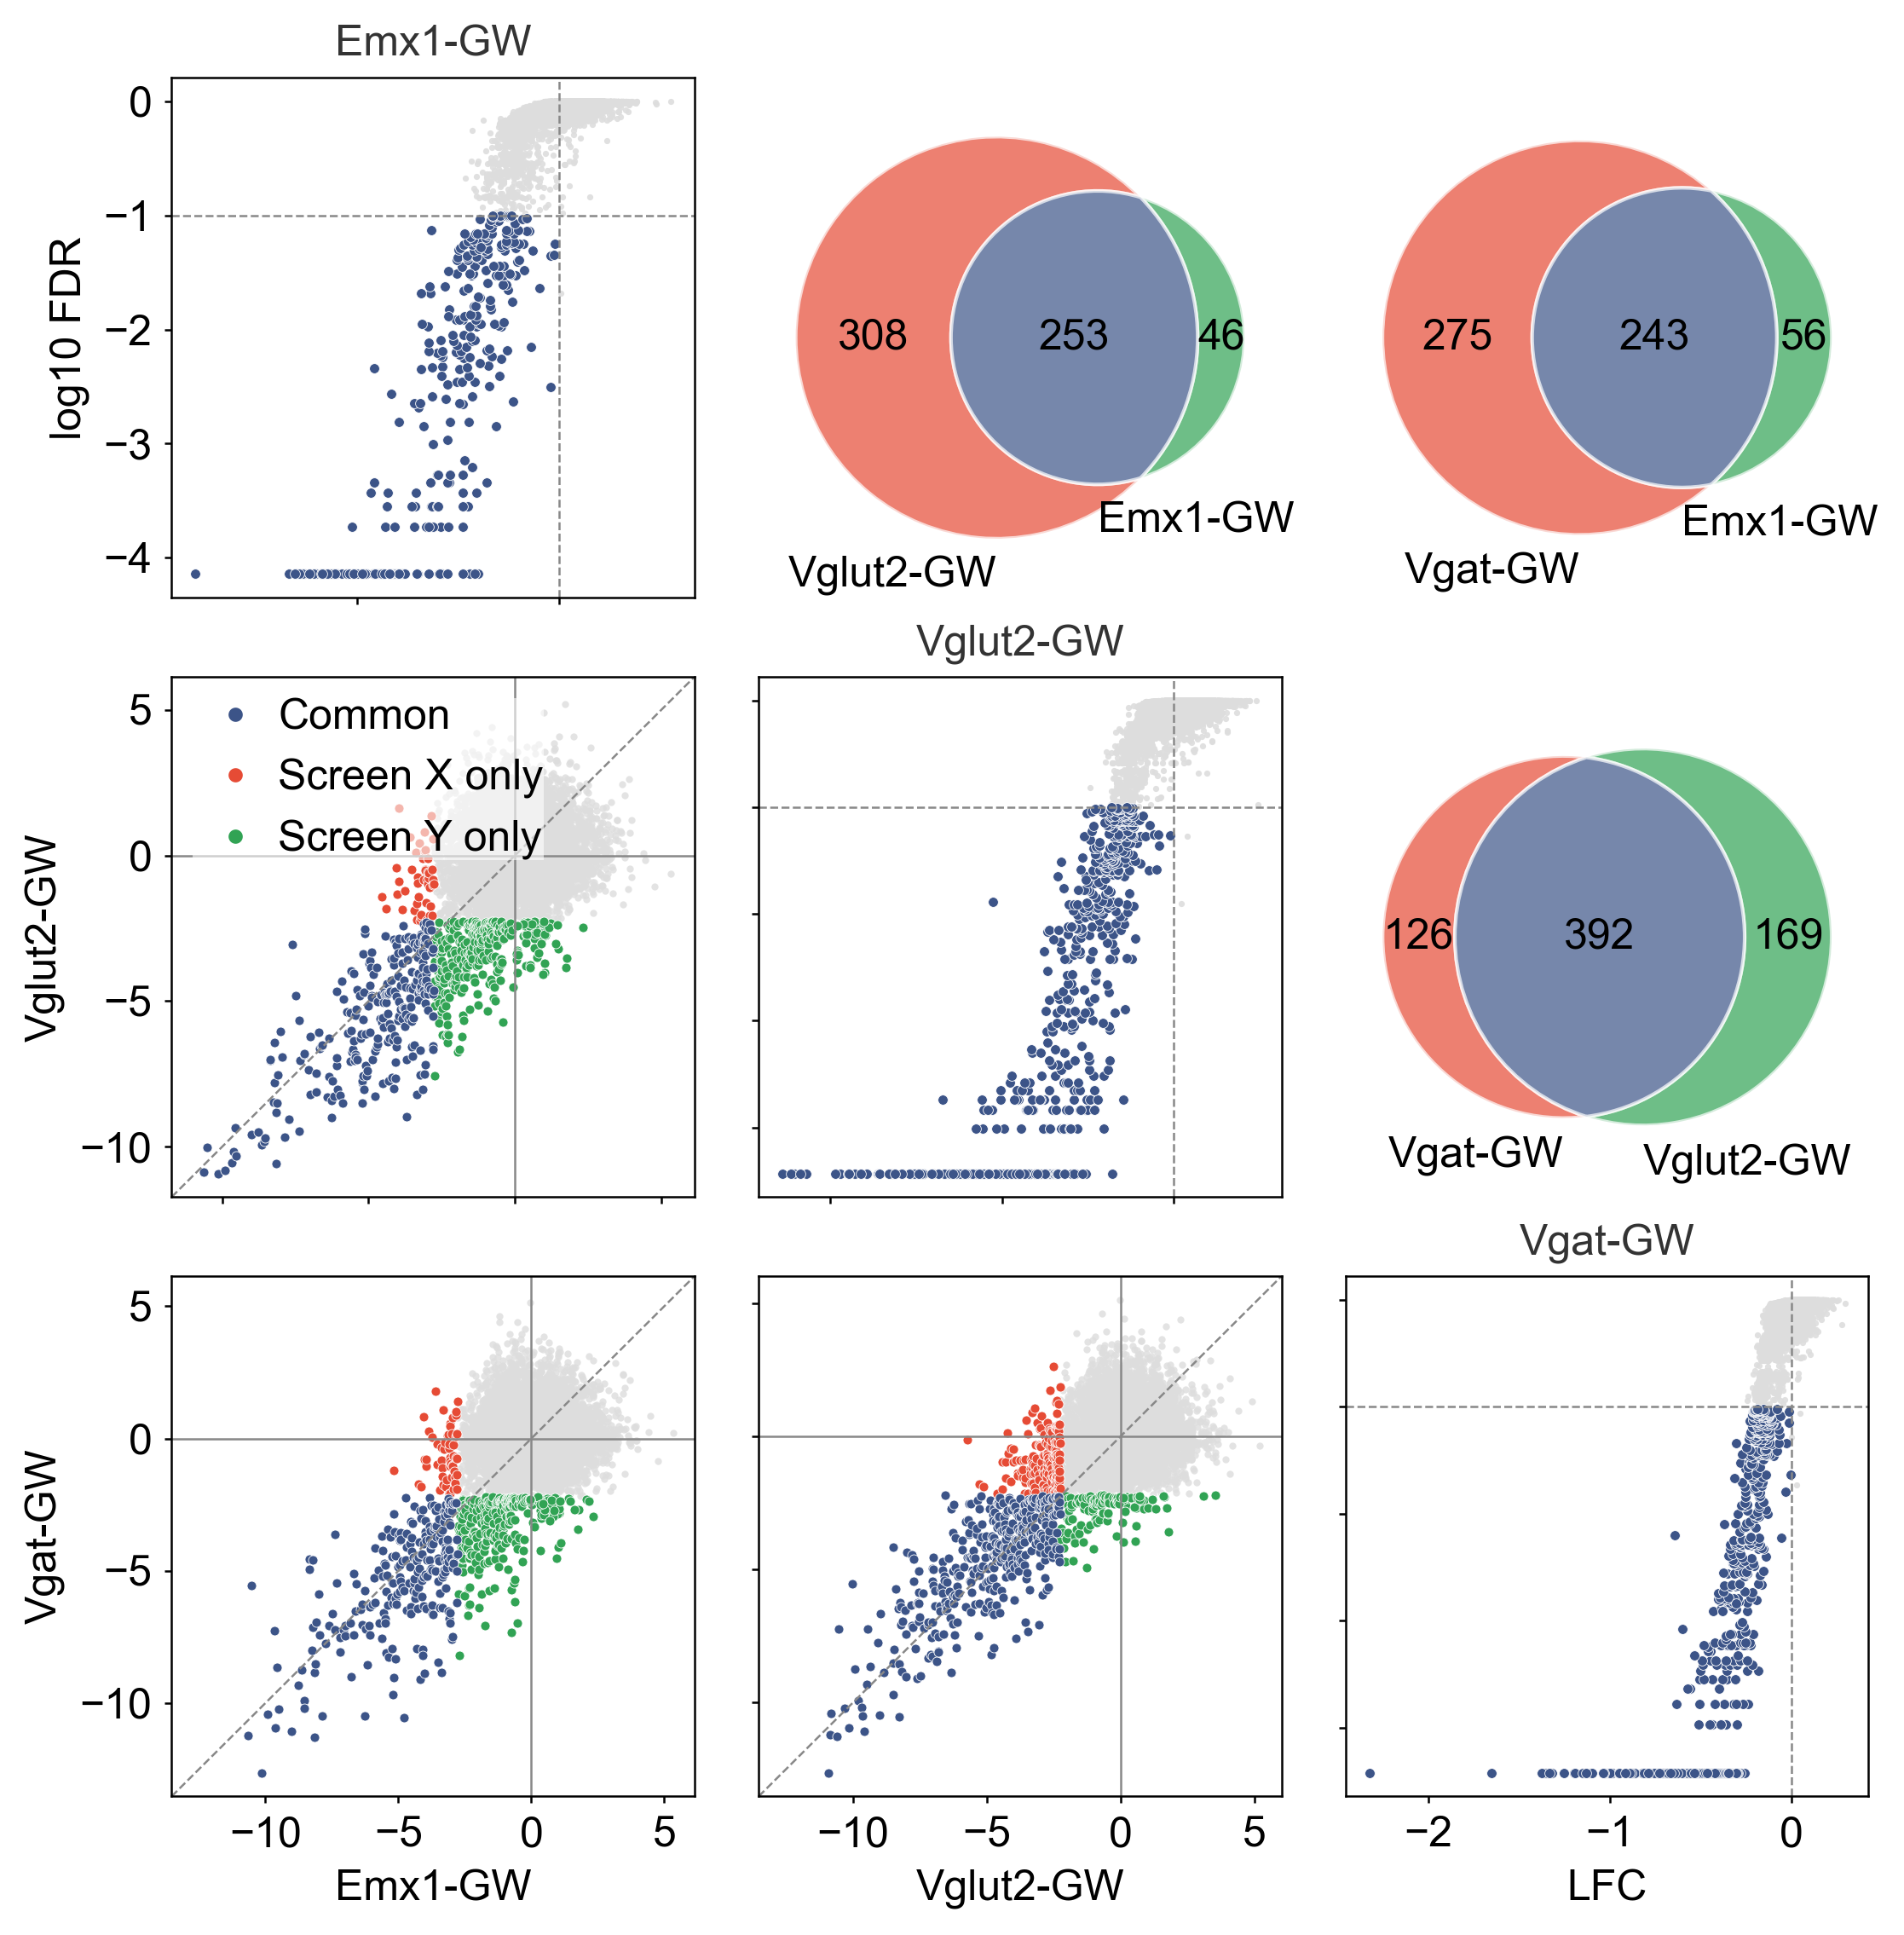

In [6]:
base_dir = "../new_mageck/"

screen_names = [
    "Emx1-GW-all_4M",
    "Vglut2-GW-all_4M",
    "Vgat-GW-all_4M",
]

screens = {}
for s in screen_names:
    f = os.path.join(base_dir, s, f"{s}.gene_summary.txt")
    screens[s] = load_screen(f, s)

n = len(screen_names)
fig, axes = plt.subplots(
    n, n,
    figsize=(2.5*n, 2.5*n),  # Reduced from 3*n
    dpi=300
)

for i, name_i in enumerate(screen_names):
    for j, name_j in enumerate(screen_names):
        ax = axes[i, j]
        short_name_i = name_i.split('-all')[0]
        short_name_j = name_j.split('-all')[0]

        if i == j:
            plot_diag(ax, screens[name_i], title=short_name_i)
            ax.tick_params(labelsize=12)  # Smaller ticks
            
        elif i > j:
            plot_offdiag(ax, screens[name_j], screens[name_i], 
                        label1=short_name_j, label2=short_name_i,
                        show_legend=(i==1 and j==0))  # Legend only once
            
        else:
            plot_offdiag_venn(ax, screens[name_j], screens[name_i],
                            label1=short_name_j, label2=short_name_i)

        # Streamlined axis cleanup
        ax.tick_params(labelsize=12)
        if i < n - 1:
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)
        if j > 0:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=0.5)
plt.savefig('../comparison/emx1_vglut2_vgat/comparing_3_screens_GW.pdf', bbox_inches='tight')